In [134]:
import pandas as pd

df = pd.read_csv("diabetesData.csv")   # or correct filename
df.head()

,Id,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,6,148,72,35,0,33.6,0.627,50,1
1,2,1,85,66,29,0,26.6,0.351,31,0
2,3,8,183,64,0,0,23.3,0.672,32,1
3,4,1,89,66,23,94,28.1,0.167,21,0
4,5,0,137,40,35,168,43.1,2.288,33,1


In [135]:
df.columns

Index(['Id', 'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
       'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [136]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2768 entries, 0 to 2767
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        2768 non-null   int64  
 1   Pregnancies               2768 non-null   int64  
 2   Glucose                   2768 non-null   int64  
 3   BloodPressure             2768 non-null   int64  
 4   SkinThickness             2768 non-null   int64  
 5   Insulin                   2768 non-null   int64  
 6   BMI                       2768 non-null   float64
 7   DiabetesPedigreeFunction  2768 non-null   float64
 8   Age                       2768 non-null   int64  
 9   Outcome                   2768 non-null   int64  
dtypes: float64(2), int64(8)
memory usage: 216.4 KB


In [137]:
df = df.drop("Id", axis=1)

In [138]:
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in cols:
    df[col] = df[col].replace(0, df[col].median())

In [139]:
df["BMI_Category"] = (df["BMI"] > 30).astype(int)
df["High_Glucose"] = (df["Glucose"] > 140).astype(int)
df["Age_Group"] = (df["Age"] > 40).astype(int)

In [ ]:
X = df.drop(["Outcome", "DiabetesPedigreeFunction"], axis=1)
y = df["Outcome"]

In [141]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [142]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [143]:
from sklearn.ensemble import RandomForestClassifier

rf_balanced = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    class_weight="balanced",   # 🔥 important
    random_state=42
)

rf_balanced.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=6, n_estimators=200,
                       random_state=42)

In [144]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train, y_train)

SVC()

In [145]:
from sklearn.metrics import accuracy_score
acc_lr= accuracy_score(y_test, lr.predict(X_test))*100
acc_rf= accuracy_score(y_test, rf_balanced.predict(X_test))*100
acc_svm =  accuracy_score(y_test, svm.predict(X_test))*100
print("LR:",acc_lr)
print("RF:",acc_rf)
print("SVM:",acc_svm)

LR: 77.07581227436823
RF: 86.10108303249098
SVM: 83.39350180505414


In [146]:
from sklearn.metrics import classification_report

y_pred = rf_balanced.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.85      0.89       367
           1       0.75      0.88      0.81       187

    accuracy                           0.86       554
   macro avg       0.84      0.87      0.85       554
weighted avg       0.87      0.86      0.86       554



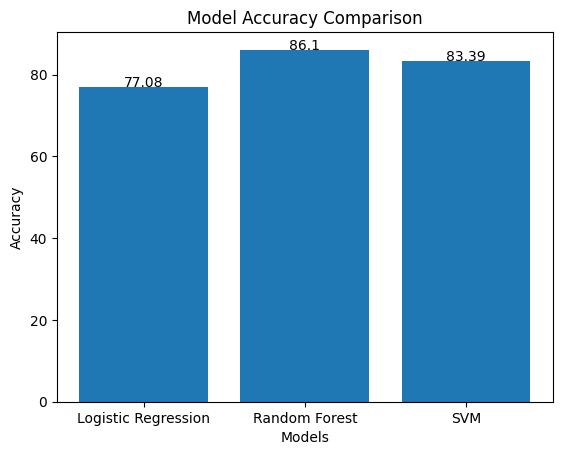

In [147]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Random Forest", "SVM"]
accuracies = [acc_lr, acc_rf, acc_svm]

plt.figure()
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

# show values on top
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{round(v, 2)}", ha='center')

plt.show()

In [148]:
import pandas as pd
from sklearn.metrics import classification_report

report_dict = classification_report(y_test, rf_balanced.predict(X_test), output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()

df_report

,precision,recall,f1-score,support
0,0.934132,0.850136,0.890157,367.000000
1,0.750000,0.882353,0.810811,187.000000
accuracy,0.861011,0.861011,0.861011,0.861011
macro avg,0.842066,0.866245,0.850484,554.000000
weighted avg,0.871979,0.861011,0.863374,554.000000


In [ ]:
import joblib

joblib.dump(rf_balanced, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']